Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    [d=2] Compiling Adam … done (2.2s)
    [d=2] Adam restart 1/6 …
      → mean=0.44551  min=0.000256  (2s)
    [d=2] Adam restart 2/6 …
      → mean=0.44474  min=0.000256  (1s)
    [d=2] Adam restart 3/6 …
      → mean=0.44474  min=0.000256  (1s)
    [d=2] Adam restart 4/6 …
      → mean=0.44474  min=0.000256  (1s)
    [d=2] Adam restart 5/6 …
      → mean=0.44474  min=0.000256  (1s)
    [d=2] Adam restart 6/6 …
      → mean=0.44474  min=0.000256  (1s)
      state  10/51  cost = 0.0125858
      state  20/51  cost = 0.0435647
      state  30/51  cost = 0.2890984
      state  40/51  cost = 0.7971292
      state  50/51  cost = 1.7956839
      state  51/51  cost = 2.0000000
    [d=2] Compiling Adam … done (2.5s)
    [d=2] Adam restart 1/6 …
      → mean=0.44474  min=0.000256  (2s)
    [d=2] Adam restart 2/6 …
      → mean=0.44474  min=0.000256  (1s)
    [d=2] A

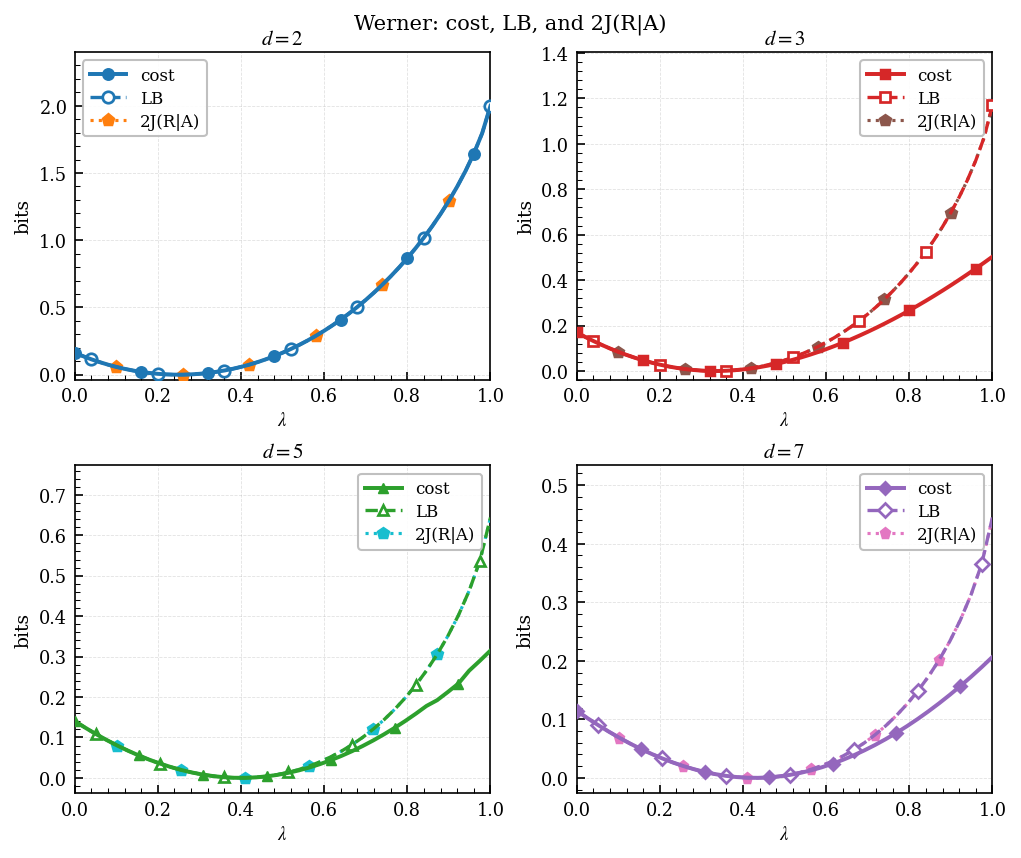


[Figure 2] Werner cost all dims …
  ✓  fig2_werner_cost_all_dims


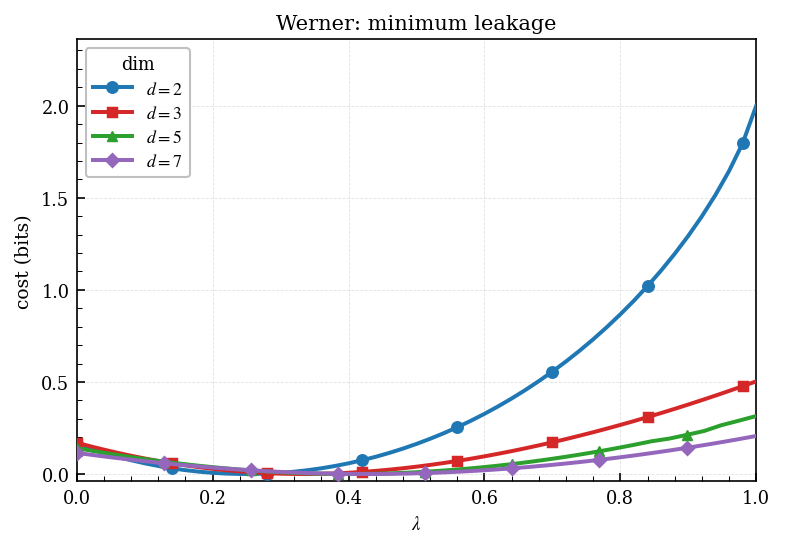


[Figure 3] Isotropic cost + LB + 2CC all dims …
  ✓  fig3_iso_cost_lb_2cc_all_dims


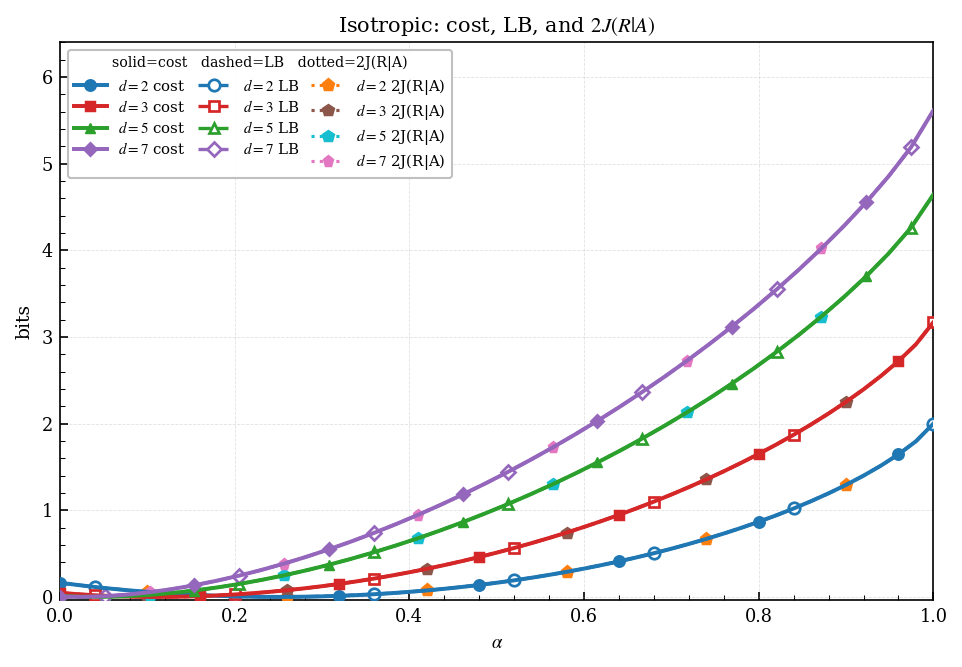


All figures saved to /content/drive/MyDrive/Iso_werner_final


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  AIMS RESEARCH — Minimum Leakage, Analytical Bounds, and Mutual Information
#  Werner and Isotropic States  ·  d ∈ {2, 3, 5, 7}
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys
for pkg in ["optax", "jaxopt"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit, grad, vmap
from functools import partial
import optax, jaxopt
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
import warnings, time, gc
from itertools import product as iproduct

warnings.filterwarnings("ignore")

from google.colab import drive
import os
drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/Iso_werner_final"
os.makedirs(SAVE_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
#  GLOBAL PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

DIMS  = [2, 3, 5, 7]
N_PTS = {2: 51, 3: 51, 5: 40, 7: 40}
OPT_CFG = {
    2: (400, 0.030, 60, 600, 6, 4),
    3: (400, 0.025, 60, 600, 5, 3),
    5: (300, 0.020, 20, 400, 3, 2),
    7: (250, 0.015,  6, 300, 2, 2),
}

_CACHE3 = {}
def dims3(d):
    if d not in _CACHE3:
        _CACHE3[d] = (d, d, d)
    return _CACHE3[d]

# ══════════════════════════════════════════════════════════════════════════════
#  MATPLOTLIB STYLE
# ══════════════════════════════════════════════════════════════════════════════

CM = 1 / 2.54

matplotlib.rcParams.update({
    "font.family"         : "serif",
    "font.serif"          : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"    : "stix",
    "font.size"           : 10,
    "axes.titlesize"      : 10,
    "axes.titleweight"    : "normal",
    "axes.labelsize"      : 9,
    "xtick.labelsize"     : 8.5,
    "ytick.labelsize"     : 8.5,
    "legend.fontsize"     : 8,
    "legend.framealpha"   : 0.92,
    "legend.edgecolor"    : "#BBBBBB",
    "legend.borderpad"    : 0.4,
    "legend.handlelength" : 2.2,
    "legend.labelspacing" : 0.35,
    "axes.linewidth"      : 0.8,
    "axes.spines.top"     : True,
    "axes.spines.right"   : True,
    "axes.grid"           : True,
    "grid.linestyle"      : "--",
    "grid.linewidth"      : 0.4,
    "grid.alpha"          : 0.35,
    "grid.color"          : "#AAAAAA",
    "xtick.direction"     : "in",
    "ytick.direction"     : "in",
    "xtick.minor.visible" : True,
    "ytick.minor.visible" : True,
    "xtick.major.width"   : 0.8,
    "ytick.major.width"   : 0.8,
    "xtick.minor.width"   : 0.5,
    "ytick.minor.width"   : 0.5,
    "xtick.major.size"    : 4.0,
    "ytick.major.size"    : 4.0,
    "xtick.minor.size"    : 2.2,
    "ytick.minor.size"    : 2.2,
    "lines.linewidth"     : 1.8,
    "figure.constrained_layout.use": True,
    "figure.dpi"          : 150,
    "savefig.dpi"         : 300,
    "savefig.bbox"        : "tight",
    "pdf.fonttype"        : 42,
})

# ── Per-curve visual identity ─────────────────────────────────────────────────
#
#  Three curve types, each with a unique combination of:
#    linestyle  |  marker shape  |  marker fill  |  colour family
#
#  cost  → solid "-",    shape varies per dim,  filled,   blue/red/green/purple
#  LB    → dashed "--",  same shape,            hollow,   same colour as cost
#  2CC   → dotted ":",   pentagon "p",          filled,   orange/brown/cyan/pink
#          (dotted is visually distinct from both solid and dashed)
#
#  Colours for 2CC are chosen to be perceptually far from the cost/LB colours.

COST_STYLE = {
    2: dict(color="#1f77b4", ls="-",  marker="o",  ms=5.5, mew=0.7, lw=1.9),
    3: dict(color="#d62728", ls="-",  marker="s",  ms=5.0, mew=0.7, lw=1.9),
    5: dict(color="#2ca02c", ls="-",  marker="^",  ms=5.0, mew=0.7, lw=1.9),
    7: dict(color="#9467bd", ls="-",  marker="D",  ms=4.5, mew=0.7, lw=1.9),
}
LB_STYLE = {
    2: dict(color="#1f77b4", ls="--", marker="o",  ms=5.5, mew=1.3, lw=1.6),
    3: dict(color="#d62728", ls="--", marker="s",  ms=5.0, mew=1.3, lw=1.6),
    5: dict(color="#2ca02c", ls="--", marker="^",  ms=5.0, mew=1.3, lw=1.6),
    7: dict(color="#9467bd", ls="--", marker="D",  ms=4.5, mew=1.3, lw=1.6),
}
CC_STYLE = {
    2: dict(color="#ff7f0e", ls=":",  marker="p",  ms=6.5, mew=0.7, lw=1.5),
    3: dict(color="#8c564b", ls=":",  marker="p",  ms=6.0, mew=0.7, lw=1.5),
    5: dict(color="#17becf", ls=":",  marker="p",  ms=6.0, mew=0.7, lw=1.5),
    7: dict(color="#e377c2", ls=":",  marker="p",  ms=5.5, mew=0.7, lw=1.5),
}


def _draw(ax, x, y, sty, me, me_start=0, filled=True, zorder=3, label=None):
    mfc = sty["color"] if filled else "white"
    return ax.plot(
        x, y,
        color=sty["color"],
        ls=sty["ls"],
        lw=sty.get("lw", 1.8),
        marker=sty["marker"],
        markersize=sty["ms"],
        markerfacecolor=mfc,
        markeredgecolor=sty["color"],
        markeredgewidth=sty["mew"],
        markevery=(me_start, me),
        zorder=zorder,
        label=label,
    )[0]


def _polish(ax, xlabel, ylabel, title=None):
    ax.set_xlabel(xlabel, labelpad=4)
    ax.set_ylabel(ylabel, labelpad=4)
    if title:
        ax.set_title(title, pad=5)
    ax.set_xlim(0, 1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))


def _autolim(ax, *arrays, pad_lo=0.07, pad_hi=0.07):
    all_v = np.concatenate([np.asarray(a).ravel() for a in arrays])
    rng   = all_v.max() - all_v.min()
    ax.set_ylim(max(-0.04, all_v.min() - pad_lo * rng),
                all_v.max() + pad_hi * rng)


def _legend_handle(sty, label, hollow=False):
    """Build a Line2D legend proxy."""
    return Line2D(
        [0], [0],
        color=sty["color"], ls=sty["ls"], lw=sty.get("lw", 1.8),
        marker=sty["marker"], markersize=sty["ms"],
        markerfacecolor="white" if hollow else sty["color"],
        markeredgecolor=sty["color"], markeredgewidth=sty["mew"],
        label=label,
    )


def save_fig(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(f"{SAVE_DIR}/{name}.{ext}", format=ext)
    print(f"  ✓  {name}")


# ══════════════════════════════════════════════════════════════════════════════
#  ANALYTIC QUANTITIES
# ══════════════════════════════════════════════════════════════════════════════

def _xlg2(x):
    return float(x * np.log2(x)) if x > 1e-15 else 0.0

def werner_I_RA(d, lam):
    t1 = np.log2(2 * d)
    t2 = _xlg2(lam) - lam * np.log2(d - 1)        if lam > 1e-15   else 0.0
    t3 = _xlg2(1-lam) - (1-lam) * np.log2(d + 1)  if lam < 1-1e-15 else 0.0
    return max(0.0, t1 + t2 + t3)

def werner_discord(d, lam):
    t1 = np.log2(d + 1)
    t2 = _xlg2(lam)    - lam    * np.log2(d - 1)   if lam > 1e-15   else 0.0
    t3 = _xlg2(1-lam)  - (1-lam)* np.log2(d + 1)   if lam < 1-1e-15 else 0.0
    t4 = -(2*(1-lam)/(d+1)) * np.log2(1-lam)        if lam < 1-1e-15 else 0.0
    a  = (d - 1 + 2*lam) / (2*(d - 1))
    t5 = -((d - 1 + 2*lam)/(d+1)) * np.log2(a)     if a  > 1e-15    else 0.0
    return max(0.0, t1 + t2 + t3 + t4 + t5)

def werner_CC(d, lam):
    return max(0.0, werner_I_RA(d, lam) - werner_discord(d, lam))

def werner_LB(d, lam):
    I = werner_I_RA(d, lam)
    D = werner_discord(d, lam)
    return max(0.0, I - abs(I - 2*D))

def isotropic_I_RA(d, F):
    lam1 = F
    lam2 = (1 - F) / (d**2 - 1) if F < 1 - 1e-15 else 0.0
    S_RA = -_xlg2(lam1) - (d**2 - 1) * _xlg2(lam2)
    return max(0.0, 2*np.log2(d) - S_RA)

def isotropic_discord(d, F):
    xi = (d*F + 1) / (d*(d + 1))
    t1 = _xlg2(F)
    t2 = ((1-F)/(d+1)) * np.log2((1-F)/(d**2-1)) if (1-F) > 1e-15 else 0.0
    t3 = -d * _xlg2(xi)
    return max(0.0, t1 + t2 + t3)

def isotropic_CC(d, F):
    xi = (d*F + 1) / (d*(d + 1))
    t1 = 2*np.log2(d)
    t2 = (d*(1-F)/(d+1)) * np.log2((1-F)/(d**2-1)) if (1-F) > 1e-15 else 0.0
    t3 = d * _xlg2(xi)
    return max(0.0, t1 + t2 + t3)

def isotropic_LB(d, F):
    I = isotropic_I_RA(d, F)
    D = isotropic_discord(d, F)
    return max(0.0, I - abs(I - 2*D))


# ══════════════════════════════════════════════════════════════════════════════
#  STATE MATRICES
# ══════════════════════════════════════════════════════════════════════════════

def flip_op(d):
    F = np.zeros((d*d, d*d), dtype=np.complex128)
    for i, j in iproduct(range(d), repeat=2):
        F[i*d+j, j*d+i] = 1.0
    return F

def werner_rho(d, lam):
    I  = np.eye(d*d, dtype=np.complex128)
    Fm = flip_op(d)
    Pp = (I + Fm) / 2
    Pm = (I - Fm) / 2
    return (2*(1-lam)/(d*(d+1))) * Pp + (2*lam/(d*(d-1))) * Pm

def isotropic_rho(d, F):
    dim = d*d
    I   = np.eye(dim, dtype=np.complex128)
    phi = np.zeros(dim, dtype=np.complex128)
    for i in range(d):
        phi[i*d+i] = 1/np.sqrt(d)
    dm  = np.outer(phi, phi.conj())
    return F * dm + (1-F)/(d**2-1) * (I - dm)


# ══════════════════════════════════════════════════════════════════════════════
#  GELL-MANN BASIS
# ══════════════════════════════════════════════════════════════════════════════

_GM_CPU = {}
_GM_GPU = {}

def _build_gm(n):
    mats = []
    for j in range(n):
        for k in range(j+1, n):
            L = np.zeros((n, n), dtype=np.complex128)
            L[j, k] = L[k, j] = 1.0
            mats.append(L)
    for j in range(n):
        for k in range(j+1, n):
            L = np.zeros((n, n), dtype=np.complex128)
            L[j, k] = -1j;  L[k, j] = 1j
            mats.append(L)
    for l in range(1, n):
        L = np.zeros((n, n), dtype=np.complex128)
        c = np.sqrt(2/(l*(l+1)))
        for j in range(l):
            L[j, j] = c
        L[l, l] = -l * c
        mats.append(L)
    return np.stack(mats).astype(np.complex128)

for d in DIMS:
    n = d*d
    G = _build_gm(n)
    _GM_CPU[n] = G
    _GM_GPU[n] = jnp.array(G)


# ══════════════════════════════════════════════════════════════════════════════
#  JAX CORE
# ══════════════════════════════════════════════════════════════════════════════

@partial(jit, static_argnums=(1, 2))
def ptrace(rho, keep, d_tuple):
    n     = len(d_tuple)
    rho_t = rho.reshape(list(d_tuple) + list(d_tuple))
    for ax in sorted([i for i in range(n) if i not in keep], reverse=True):
        rho_t = jnp.trace(rho_t, axis1=ax, axis2=ax + rho_t.ndim//2)
    d_k = int(np.prod([d_tuple[i] for i in sorted(keep)]))
    return rho_t.reshape(d_k, d_k)

@jit
def S(rho):
    ev   = jnp.linalg.eigvalsh(rho).real
    ev   = jnp.clip(ev, 0.0)
    ev   = ev / jnp.maximum(ev.sum(), 1e-30)
    safe = jnp.where(ev > 1e-15, ev, jnp.ones_like(ev))
    return -jnp.sum(jnp.where(ev > 1e-15, ev * jnp.log2(safe), 0.0))

def cayley_U(params, d):
    n  = d*d
    G  = _GM_GPU[n]
    H  = jnp.einsum("k,kij->ij", params.astype(jnp.complex128), G)
    I  = jnp.eye(n, dtype=jnp.complex128)
    return jnp.linalg.solve((I + 1j*H + 1e-8*I).T, (I - 1j*H).T).T

def n_params(d):
    return d**4 - 1

def rand_params(d, rng, scale_factor=1.0):
    n     = d*d
    scale = scale_factor * np.pi / np.sqrt(n)
    return rng.uniform(-scale, scale, n**2-1).astype(np.float64)

@partial(jit, static_argnums=(2,))
def leakage(params, rho_RA, d):
    U      = cayley_U(params, d)
    ket0   = jnp.zeros(d, dtype=jnp.complex128).at[0].set(1.0)
    rho_E0 = jnp.outer(ket0, ket0)
    I_R    = jnp.eye(d, dtype=jnp.complex128)
    sigma  = jnp.kron(I_R, U) @ jnp.kron(rho_RA, rho_E0) \
             @ jnp.kron(I_R, U).conj().T
    dt     = dims3(d)
    sig_R  = ptrace(sigma, (0,),    dt)
    sig_B  = ptrace(sigma, (1,),    dt)
    sig_E  = ptrace(sigma, (2,),    dt)
    sig_RB = ptrace(sigma, (0, 1),  dt)
    sig_RE = ptrace(sigma, (0, 2),  dt)
    IRB    = S(sig_R) + S(sig_B) - S(sig_RB)
    IRE    = S(sig_R) + S(sig_E) - S(sig_RE)
    return (IRB + IRE).real


# ══════════════════════════════════════════════════════════════════════════════
#  OPTIMISER
# ══════════════════════════════════════════════════════════════════════════════

def _adam_sched(lr, steps):
    return optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(optax.warmup_cosine_decay_schedule(
            init_value=lr*0.05, peak_value=lr,
            warmup_steps=max(80, steps//8),
            decay_steps=steps, end_value=lr*0.01,
        ))
    )

def _compile_batched_step(optimizer, d):
    _g = jit(vmap(grad(partial(leakage, d=d)), in_axes=(0, 0)))
    _c = jit(vmap(partial(leakage, d=d),       in_axes=(0, 0)))
    @jit
    def step(params, opt_st, rhos):
        gs           = _g(params, rhos)
        upd, new_st  = jit(vmap(optimizer.update))(gs, opt_st)
        new_p        = jit(vmap(optax.apply_updates))(params, upd)
        return new_p, new_st, _c(new_p, rhos)
    return step

def _compile_single_step(optimizer, d):
    _gfn = jit(grad(partial(leakage, d=d)))
    _cfn = jit(partial(leakage, d=d))
    @jit
    def step(params, opt_st, rho):
        g           = _gfn(params, rho)
        upd, new_st = optimizer.update(g, opt_st)
        new_p       = optax.apply_updates(params, upd)
        return new_p, new_st, _cfn(new_p, rho)
    return step


def adam_phase(rho_list, d, lr, n_steps, chunk_sz, n_restarts, rng):
    optimizer = _adam_sched(lr, n_steps)
    n_pts     = len(rho_list)
    batched   = chunk_sz > 1

    print(f"    [d={d}] Compiling Adam … ", end="", flush=True)
    t_c = time.time()
    if batched:
        step_fn = _compile_batched_step(optimizer, d)
        p0  = jnp.array(np.stack([rand_params(d, rng) for _ in range(chunk_sz)]))
        o0  = jit(vmap(optimizer.init))(p0)
        r0  = jnp.stack([jnp.array(rho_list[0])] * chunk_sz)
        step_fn(p0, o0, r0)
        del p0, o0, r0
    else:
        step_fn = _compile_single_step(optimizer, d)
        p0 = jnp.array(rand_params(d, rng)); o0 = optimizer.init(p0)
        step_fn(p0, o0, jnp.array(rho_list[0]))
        del p0, o0
    gc.collect()
    print(f"done ({time.time()-t_c:.1f}s)")

    best_cost   = np.full(n_pts, np.inf)
    best_params = [rand_params(d, rng) for _ in range(n_pts)]

    for restart in range(n_restarts):
        t0 = time.time()
        print(f"    [d={d}] Adam restart {restart+1}/{n_restarts} …", flush=True)
        if not batched:
            for gi, rho_np in enumerate(rho_list):
                rho = jnp.array(rho_np)
                p   = jnp.array(rand_params(d, rng))
                o   = optimizer.init(p)
                for _ in range(n_steps):
                    p, o, c = step_fn(p, o, rho)
                c = float(c)
                if c < best_cost[gi]:
                    best_cost[gi] = c;  best_params[gi] = np.array(p)
                del rho, p, o;  gc.collect()
        else:
            for i in range(0, n_pts, chunk_sz):
                idx  = list(range(i, min(i+chunk_sz, n_pts)))
                nc   = len(idx)
                rhos = jnp.stack([jnp.array(rho_list[j]) for j in idx])
                ps   = jnp.array(np.stack([rand_params(d, rng) for _ in range(nc)]))
                if nc < chunk_sz:
                    pad_r = chunk_sz - nc
                    rhos  = jnp.concatenate([rhos, jnp.zeros((pad_r,)+rhos.shape[1:], dtype=rhos.dtype)])
                    ps    = jnp.concatenate([ps,   jnp.zeros((pad_r,)+ps.shape[1:],   dtype=ps.dtype)])
                os = jit(vmap(optimizer.init))(ps)
                for _ in range(n_steps):
                    ps, os, costs = step_fn(ps, os, rhos)
                for k, gi in enumerate(idx):
                    c = float(costs[k])
                    if c < best_cost[gi]:
                        best_cost[gi] = c;  best_params[gi] = np.array(ps[k])
                del rhos, ps, os;  gc.collect()
        print(f"      → mean={best_cost.mean():.5f}  min={best_cost.min():.6f}  ({time.time()-t0:.0f}s)")

    return best_params, best_cost


@partial(jit, static_argnums=(2,))
def _cost_from_U_static(rho_RA, U, d):
    ket0   = jnp.zeros(d, dtype=jnp.complex128).at[0].set(1.0)
    rho_E0 = jnp.outer(ket0, ket0)
    I_R    = jnp.eye(d, dtype=jnp.complex128)
    sigma  = jnp.kron(I_R, U) @ jnp.kron(rho_RA, rho_E0) \
             @ jnp.kron(I_R, U).conj().T
    dt     = dims3(d)
    sig_R  = ptrace(sigma, (0,),    dt)
    sig_B  = ptrace(sigma, (1,),    dt)
    sig_E  = ptrace(sigma, (2,),    dt)
    sig_RB = ptrace(sigma, (0, 1),  dt)
    sig_RE = ptrace(sigma, (0, 2),  dt)
    IRB    = S(sig_R) + S(sig_B) - S(sig_RB)
    IRE    = S(sig_R) + S(sig_E) - S(sig_RE)
    return (IRB + IRE).real


def lbfgs_phase(rho_list, d, init_params, best_cost, n_iters, n_extra, rng):
    fn     = lambda p, r: _cost_from_U_static(r, cayley_U(p, d), d)
    solver = jaxopt.LBFGS(fun=fn, maxiter=n_iters, tol=1e-12,
                          implicit_diff=False, history_size=40)
    n_pts  = len(rho_list)
    for gi, rho_np in enumerate(rho_list):
        rho   = jnp.array(rho_np)
        inits = [init_params[gi]] + [rand_params(d, rng) for _ in range(n_extra)]
        for p0 in inits:
            sol = solver.run(jnp.array(p0), rho)
            c   = float(fn(sol.params, rho))
            if c < best_cost[gi]:
                best_cost[gi] = c;  init_params[gi] = np.array(sol.params)
        if (gi+1) % max(1, n_pts//5) == 0 or gi == n_pts-1:
            print(f"      state {gi+1:3d}/{n_pts}  cost = {best_cost[gi]:.7f}")
    return best_cost


def optimize(rho_list, d, seed=42):
    steps, lr, chunk, lbfgs_iters, n_adam, n_lbfgs = OPT_CFG[d]
    rng = np.random.default_rng(seed)
    init_p, best_c = adam_phase(rho_list, d, lr, steps, chunk, n_adam, rng)
    best_c = lbfgs_phase(rho_list, d, init_p, best_c, lbfgs_iters, n_lbfgs, rng)
    return best_c


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN COMPUTATION LOOP
# ══════════════════════════════════════════════════════════════════════════════

werner_data    = {}
isotropic_data = {}

for d in DIMS:
    n_pts = N_PTS[d]
    LAM   = np.linspace(0.0, 1.0, n_pts)
    F_arr = np.linspace(0.0, 1.0, n_pts)

    # ── Werner ────────────────────────────────────────────────────────────────
    W = dict(
        x     = LAM,
        I_RA  = np.array([werner_I_RA(d, l)   for l in LAM]),
        disc  = np.array([werner_discord(d, l) for l in LAM]),
        CC    = np.array([werner_CC(d, l)      for l in LAM]),
        LB    = np.array([werner_LB(d, l)      for l in LAM]),
    )
    W["CC2"] = 2 * W["CC"]          # ← 2·C← added here
    rho_W      = [werner_rho(d, l) for l in LAM]
    W['cost']  = optimize(rho_W, d, seed=42)
    werner_data[d] = W
    del rho_W;  gc.collect()

    # ── Isotropic ─────────────────────────────────────────────────────────────
    ISO = dict(
        x     = F_arr,
        I_RA  = np.array([isotropic_I_RA(d, F)   for F in F_arr]),
        disc  = np.array([isotropic_discord(d, F) for F in F_arr]),
        CC    = np.array([isotropic_CC(d, F)      for F in F_arr]),
        LB    = np.array([isotropic_LB(d, F)      for F in F_arr]),
    )
    ISO["CC2"]  = 2 * ISO["CC"]     # ← 2·C← added here
    rho_I       = [isotropic_rho(d, F) for F in F_arr]
    ISO['cost'] = optimize(rho_I, d, seed=123)
    isotropic_data[d] = ISO
    del rho_I;  gc.collect()


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 1  —  2×2 Werner: cost + LB + 2CC per panel
#
#  Visual separation strategy (3 curves per panel, same x-range):
#    cost → solid "-",   filled marker (shape varies per d),  full opacity
#    LB   → dashed "--", hollow marker (same shape),          full opacity
#    2CC  → dotted ":",  pentagon "p", filled, CC_STYLE colour (always distinct)
#
#  Marker positions staggered: cost at 0, LB at me//3, 2CC at 2*me//3
#  so the three marker clouds never pile on top of each other.
# ══════════════════════════════════════════════════════════════════════════════

print("\n[Figure 1] Werner 2×2 per-dimension (cost + LB + 2CC) …")

fig1, axes1 = plt.subplots(2, 2, figsize=(17*CM, 14*CM))
axes1_flat  = axes1.flatten()

for idx, d in enumerate(DIMS):
    ax  = axes1_flat[idx]
    res = werner_data[d]
    x   = res["x"]
    n   = len(x)
    me  = max(1, n // 6)

    _draw(ax, x, res["cost"], COST_STYLE[d], me, me_start=0,        filled=True,  zorder=5, label="cost")
    _draw(ax, x, res["LB"],   LB_STYLE[d],   me, me_start=me//3,    filled=False, zorder=4, label="LB")
    _draw(ax, x, res["CC2"],  CC_STYLE[d],   me, me_start=2*me//3,  filled=True,  zorder=3, label="2J(R|A)")

    _autolim(ax, res["cost"], res["LB"], res["CC2"], pad_lo=0.06, pad_hi=0.20)
    ax.set_xlim(0, 1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.set_title(rf"$d = {d}$", pad=4)
    ax.set_xlabel(r"$\lambda$", labelpad=3)
    ax.set_ylabel("bits", labelpad=3)
    ax.legend(loc="best", fontsize=8)

fig1.suptitle("Werner: cost, LB, and 2J(R|A)", y=1.01, fontsize=10)
save_fig(fig1, "fig1_werner_2x2")
plt.show();  plt.close(fig1)


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 2  —  Werner cost only, all 4 dimensions on one panel
#  (unchanged structure — just one solid curve per dim, clearly distinguishable
#   by colour + marker + linestyle from DIM_STYLE)
# ══════════════════════════════════════════════════════════════════════════════

print("\n[Figure 2] Werner cost all dims …")

fig2, ax2 = plt.subplots(figsize=(13*CM, 9*CM))

for d in DIMS:
    res = werner_data[d]
    x   = res["x"]
    n   = len(x)
    me  = max(1, n // 7)
    _draw(ax2, x, res["cost"], COST_STYLE[d], me, me_start=0,
          filled=True, zorder=4, label=rf"$d={d}$")

_autolim(ax2, *[werner_data[d]["cost"] for d in DIMS], pad_lo=0.06, pad_hi=0.18)
_polish(ax2,
        xlabel=r"$\lambda$",
        ylabel="cost (bits)",
        title="Werner: minimum leakage")
ax2.legend(loc="best", fontsize=8.5, title="dim", title_fontsize=8.5)
save_fig(fig2, "fig2_werner_cost_all_dims")
plt.show();  plt.close(fig2)


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 3  —  Isotropic: cost + LB + 2CC, all 4 dimensions
#
#  12 curves total.  Kept distinguishable by:
#    • colour  : cost/LB share the dimension colour (blue/red/green/purple)
#                2CC uses a separate palette (orange/brown/cyan/pink)
#    • line    : cost solid, LB dashed, 2CC dotted  → three linestyle families
#    • marker  : cost/LB use shape-per-dim (o/s/^/D), 2CC always pentagon "p"
#    • fill    : cost filled, LB hollow, 2CC filled
#    • density : marker positions staggered across the three curve types
#    • z-order : cost on top, then LB, then 2CC
# ══════════════════════════════════════════════════════════════════════════════

print("\n[Figure 3] Isotropic cost + LB + 2CC all dims …")

fig3, ax3 = plt.subplots(figsize=(16*CM, 11*CM))

for d in DIMS:
    res = isotropic_data[d]
    x   = res["x"]
    n   = len(x)
    me  = max(1, n // 6)

    _draw(ax3, x, res["cost"], COST_STYLE[d], me, me_start=0,       filled=True,  zorder=5, label=rf"$d={d}$ cost")
    _draw(ax3, x, res["LB"],   LB_STYLE[d],   me, me_start=me//3,   filled=False, zorder=4, label=rf"$d={d}$ LB")
    _draw(ax3, x, res["CC2"],  CC_STYLE[d],   me, me_start=2*me//3, filled=True,  zorder=3, label=rf"$d={d}$ J(R|A)")

all_y3 = [isotropic_data[d][k] for d in DIMS for k in ("cost", "LB", "CC2")]
_autolim(ax3, *all_y3, pad_lo=0.05, pad_hi=0.14)
_polish(ax3,
        xlabel=r"$\alpha$",
        ylabel="bits",
        title=r"Isotropic: cost, LB, and $2J(R|A)$")

# ── Three-column legend, one column per curve type ────────────────────────────
cost_h = [_legend_handle(COST_STYLE[d], rf"$d={d}$ cost", hollow=False) for d in DIMS]
lb_h   = [_legend_handle(LB_STYLE[d],   rf"$d={d}$ LB",   hollow=True)  for d in DIMS]
cc_h   = [_legend_handle(CC_STYLE[d],   rf"$d={d}$ 2J(R|A)",  hollow=False) for d in DIMS]

ax3.legend(
    handles=cost_h + lb_h + cc_h,
    ncol=3, loc="best",
    fontsize=7.2, columnspacing=0.8, handlelength=2.2,
    title="solid=cost   dashed=LB   dotted=2J(R|A)",
    title_fontsize=6.8,
    framealpha=0.93, edgecolor="#BBBBBB",
)

save_fig(fig3, "fig3_iso_cost_lb_2cc_all_dims")
plt.show();  plt.close(fig3)


print("\nAll figures saved to", SAVE_DIR)